# Stellar-metallicity feasibility scoping — CG4 satellites vs controls

**Isolated, read-only exploration.** Everything this notebook writes lives under `exploration/metallicity/`;
every pre-existing repository file is opened read-only. No number below is typed by hand: each cell runs the
corresponding phase script and then renders tables from `outputs/metallicity_scoping.json`.

| phase | script | writes |
|---|---|---|
| 0 inventory | `phase0_inventory.py` | `INVENTORY.md`, JSON `phase0` |
| 1 extraction | `phase1_fetch.py`, `phase1_assemble.py` | `work/*`, blind table + key, JSON `phase1` |
| 2 census & power (blinded) | `phase2_census_power.py` | `figures/fig_power_vs_SN.png`, JSON `phase2` |
| 3 systematics (blinded) | `phase3_systematics.py` | `figures/fig_aperture_bias.png`, `figures/fig_degeneracy_plane.png`, JSON `phase3` |
| 4 unblinded contrasts | `phase4_fetch_hosts.py`, `phase4_unblinded.py` | `figures/fig_phase4_contrasts.png`, `outputs/usable_satellites.csv`, JSON `phase4` |
| 5 report | `phase5_report.py` | `REPORT.md` |

Gates A/B/C are recorded in the session log; the JSON frozen before unblinding is `outputs/metallicity_scoping_preunblind_snapshot.json`
(sha256 in `outputs/PREUNBLIND_SHA256.txt`).

In [1]:
import json, os, subprocess, sys
from IPython.display import Image, Markdown, display
import pandas as pd
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.precision", 3)

HERE = os.path.abspath("")                       # exploration/metallicity
assert HERE.endswith(os.path.join("exploration", "metallicity")), HERE
REPO = os.path.abspath(os.path.join(HERE, "..", ".."))
PY = sys.executable
JSON_PATH = os.path.join(HERE, "outputs", "metallicity_scoping.json")

def run(script, tail=12):
    r = subprocess.run([PY, os.path.join(HERE, script)], cwd=REPO, capture_output=True, text=True)
    lines = [l for l in (r.stdout + r.stderr).splitlines() if "Warning" not in l and "warnings.warn" not in l]
    print("\n".join(lines[-tail:]))
    if r.returncode != 0:
        raise RuntimeError(f"{script} failed (exit {r.returncode})")

def J():
    with open(JSON_PATH) as fh:
        return json.load(fh)

print(subprocess.run(["git", "status", "--porcelain"], cwd=REPO, capture_output=True, text=True).stdout)

 M output/paper/paper.aux
 M output/paper/paper.pdf
 M output/paper/paper.tex
 M src/paper_template/paper_template.tex
 M tests/test_size_render_smoke.py
?? exploration/
?? referee/T10_ds18_morphology.py
?? referee/values/T10.json
?? tmp/



## Phase 0 — Inventory

In [2]:
run("phase0_inventory.py", tail=3)
p0 = J()["phase0"]
rows = []
for s, e in p0["samples"].items():
    r = e["specobjid_run2d_distribution"]
    rows.append({"sample": s, "N_groups": e["N_groups"], "N_gals": e["N_gals"], "N_BGG": e["N_BGG_rankM_eq_1"], "N_sat": e["N_sat_rankM_gt_1"],
                 "in_SDSS_cache": e["N_in_SDSS_cache_by_objid"], "run2d=26": r.get("26", 0), "run2d=700 (BOSS)": r.get("700", 0),
                 "Rchl_r_valid_sat": e["size_cache"]["N_sat_Rchl_r_valid"], "NoGZ": e["morphology_counts"].get("NoGZ", 0)})
display(pd.DataFrame(rows))
a = p0["availability"]
display(Markdown(f"**galSpecIndx downloaded:** {a['galSpecIndx_downloaded']} — **per-galaxy σ local:** {a['velocity_dispersion_per_galaxy_local']} — "
                 f"**spectrum S/N local:** {a['spectrum_sn_per_galaxy_local']}  \nJoin key: {p0['join']['canonical_galaxy_key']}  \nBGG flag: {p0['join']['bgg_flag']}"))

- Control4B: 152 rows where csv `specobjid` ≠ size-cache `specObjID`; of these 149 share plate/fiber/MJD (run2d 700→1300 re-reduction), the remainder are objects with a different spectrum chosen by the bestObjID join; 2 rows have specobjid=0.
- Control4C: 170 rows where csv `specobjid` ≠ size-cache `specObjID`; of these 164 share plate/fiber/MJD (run2d 700→1300 re-reduction), the remainder are objects with a different spectrum chosen by the bestObjID join; 0 rows have specobjid=0.



,sample,N_groups,N_gals,N_BGG,N_sat,in_SDSS_cache,run2d=26,run2d=700 (BOSS),Rchl_r_valid_sat,NoGZ
0,CG4,62,248,62,186,217,234,14,173,31
1,RG4,56,224,56,168,204,219,5,162,20
2,Control4B,698,2792,698,2094,2488,2641,149,1721,304
3,Control4C,703,2812,703,2109,2491,2648,164,1842,321


**galSpecIndx downloaded:** False — **per-galaxy σ local:** False — **spectrum S/N local:** False  
Join key: objid (SDSS DR16 photometric objID; src/identity.py: one physical galaxy = one objid)  
BGG flag: rank_M == 1 -> BGG; rank_M > 1 -> satellite (src/extended_data.py, 'is_bgg' / 'is_satellite')

## Phase 1 — Index extraction (MPA-JHU `galSpecIndx` + `galSpecInfo` + `SpecObjAll`)
The fetch is cached in `work/cas_spectra_raw.csv`; rerunning is offline.

In [3]:
run("phase1_fetch.py", tail=4)
run("phase1_assemble.py", tail=0)
p1 = J()["phase1"]
ja = p1["join_accounting"]
rows = []
for s in ["CG4", "RG4", "Control4B", "Control4C", "ALL"]:
    for tag in ["all", "satellites"]:
        a = ja[s][tag]
        rows.append({"sample": s, "subset": tag, "N_input": a["N_input"], "any_spectrum": a["N_any_spectrum"], "MPA_result": a["N_mpa_result"],
                     "reliable": a["N_mpa_reliable"], "core7_valid": a["N_valid_core7"], "core7+sigma+SN": a["N_valid_core7_and_sigma_and_SN"], "MgFe_valid": a["N_valid_MgFe"]})
display(pd.DataFrame(rows))
display(pd.DataFrame(ja["loss_reason_by_sample_satellites"]).fillna(0).astype(int).T)
dm = p1["datamodel_verification"]
display(Markdown("\n".join(f"- **{k}**: {v['status'] if isinstance(v, dict) and 'status' in v else v}" for k, v in dm.items() if k != "sources")))
sn = {k: v for k, v in p1["sentinel_notes"].items() if isinstance(v, dict)}
display(pd.DataFrame(sn).T[["n_err_minus1", "z_p10_p50_p90_of_flagged"]])
display(Markdown(p1["sentinel_notes"]["interpretation"]))
display(Markdown(f"Blinding: {p1['blinding']}"))

samples: 6076 rows, 3857 unique objids
raw spectra fetched: 4086 rows; columns=96
chosen spectra: 3857 objids; choice counts={'csv_specobjid_with_mpa': 3647, 'other_no_mpa': 205, 'other_legacy_with_mpa': 5}
-> /Users/matt/Astrophysics/CG_Gals/exploration/metallicity/work/metallicity_worktable_raw.csv: (6076, 145)  (0s)


=== Phase 1 join accounting (N_input -> any spectrum -> MPA result -> reliable -> 7 core indices valid -> +sigma+SN) ===
CG4        all          248 ->   248 ->   234 ->   234 ->   228 ->   224   (sub: 228)
CG4        satellites   186 ->   186 ->   177 ->   177 ->   172 ->   168   (sub: 172)
RG4        all          224 ->   224 ->   219 ->   219 ->   215 ->   211   (sub: 215)
RG4        satellites   168 ->   168 ->   166 ->   166 ->   163 ->   159   (sub: 163)
Control4B  all         2792 ->  2792 ->  2645 ->  2642 ->  2583 ->  2557   (sub: 2583)
Control4B  satellites  2094 ->  2094 ->  1995 ->  1992 ->  1943 ->  1917   (sub: 1943)
Control4C  all         2812 ->  2812 ->  2650 ->  2648 ->  2589 ->  2543   (sub: 2589)
Control4C  satellites  2109 ->  2109 ->  1996 ->  1994 ->  1945 ->  1899   (sub: 1945)
ALL        all         6076 ->  6076 ->  5748 ->  5743 ->  5615 ->  5535   (sub: 5615)
ALL        satellites  4557 ->  4557 ->  4334 ->  4329 ->  4223 ->  4143   (sub: 4223)

loss reasons

,sample,subset,N_input,any_spectrum,MPA_result,reliable,core7_valid,core7+sigma+SN,MgFe_valid
0,CG4,all,248,248,234,234,228,224,228
1,CG4,satellites,186,186,177,177,172,168,172
2,RG4,all,224,224,219,219,215,211,212
3,RG4,satellites,168,168,166,166,163,159,160
4,Control4B,all,2792,2792,2645,2642,2583,2557,2584
5,Control4B,satellites,2094,2094,1995,1992,1943,1917,1942
6,Control4C,all,2812,2812,2650,2648,2589,2543,2578
7,Control4C,satellites,2109,2109,1996,1994,1945,1899,1932
8,ALL,all,6076,6076,5748,5743,5615,5535,5602
9,ALL,satellites,4557,4557,4334,4329,4223,4143,4206


,ok,no_MPA_result(BOSS/not-run),core_index_missing_or_zeroed,sigma_invalid
CG4,168,9,5,4
RG4,159,2,3,4
Control4B,1917,99,52,26
Control4C,1899,113,51,46


- **resolution_system**: UNRESOLVED (explicit statement absent); strong indirect evidence for native SDSS resolution
- **velocity_dispersion_correction**: VERIFIED (indirect): no broadening correction is applied to the measured indices
- **units_and_sign**: VERIFIED from datamodel (units) + empirical check (sign)
- **emission_subtraction**: VERIFIED
- **missing_values**: VERIFIED
- **velocity_dispersion_definition**: galSpecInfo.v_disp = 'Velocity dispersion from Schlegel' (spZbest, km/s); galSpecInfo.sn_median = 'Median S/N per pixel of the whole spectrum'

,n_err_minus1,z_p10_p50_p90_of_flagged
lick_fe5335,104,"[0.0397593326, 0.04031754, 0.0407929676]"
lick_mg2,115,"[0.0391618356, 0.039736937, 0.040282729]"
lick_hd_a,18,"[0.018529920800000002, 0.0281957795, 0.0427581..."
lick_fe5270,5,"[0.0326802676, 0.044199001, 0.0445725106]"
lick_mgb,2,"[0.03326062, 0.03326062, 0.03326062]"
lick_hb,0.0,NaN
lick_hg_a,7,"[0.018598343, 0.030898258, 0.040369845]"


flagged Fe5335/Mg2 cluster at z~0.040 where the red pseudo-continuum (5301-5366 A rest) reaches the 5577 A [OI] sky line -> redshift-dependent loss of Fe5335 and hence [MgFe]'

Blinding: {'seed': 20260912, 'scheme': "permute 'sample' across (sample, group_uid) units, then rename the permuted label to a neutral S1..S4; opaque group ids", 'n_units': 1519, 'blind_table': 'work/metallicity_worktable_blind.csv', 'key': 'work/blind_key.json'}

## Phase 2 — Usability census and power (BLINDED labels S1–S4)

=== S/N census (pooled, deduplicated; require 7 core indices valid) ===
thr   all    sat    bgg  | per blinded label: sat (N_g>=1sat)
  0   3564   2864    700  | S1:1956(701)  S2:1942(697)  S3:153(56)  S4:172(60)
 10   3430   2730    700  | S1:1854(700)  S2:1838(694)  S3:147(56)  S4:166(60)
 15   3078   2378    700  | S1:1611(685)  S2:1596(688)  S3:134(55)  S4:141(59)
 20   2753   2055    698  | S1:1405(654)  S2:1362(664)  S3:113(52)  S4:117(56)
 25   2359   1668    691  | S1:1126(599)  S2:1098(602)  S3:94(48)  S4:100(54)
 30   1915   1241    674  | S1:828(490)  S2:813(499)  S3:73(42)  S4:65(40)

=== decisive (S/N>20, satellites, pooled dedup) ===
surviving 2055/3092 = 0.665
M_r full p25/p50/p75: [-21.29, -20.64, -19.96]  survivors: [-21.48, -20.96, -20.35]
lgm full p25/p50/p75: [9.96, 10.32, 10.67]  survivors: [10.21, 10.51, 10.76]
survival by M_r quartile (Q1=brightest): {'Q1': 0.912, 'Q2': 0.796, 'Q3': 0.603, 'Q4': 0.348}
fraction of survivors in brightest M_r quartile: 0.343

=== p

,S/N >,pooled all,pooled sat,pooled BGG,S1 sat (groups),S2 sat (groups),S3 sat (groups),S4 sat (groups)
0,0,3564,2864,700,1956 (701),1942 (697),153 (56),172 (60)
1,10,3430,2730,700,1854 (700),1838 (694),147 (56),166 (60)
2,15,3078,2378,700,1611 (685),1596 (688),134 (55),141 (59)
3,20,2753,2055,698,1405 (654),1362 (664),113 (52),117 (56)
4,25,2359,1668,691,1126 (599),1098 (602),94 (48),100 (54)
5,30,1915,1241,674,828 (490),813 (499),73 (42),65 (40)


**S/N>20:** 2055/3092 = 66.5% of satellites survive; survival by M_r quartile (bright→faint): [0.91, 0.8, 0.6, 0.35]; by log M* quartile (low→high): [0.27, 0.65, 0.9, 0.97]; fraction of survivors in the brightest quartile: 0.34

,"(0.0, 5.0]","(5.0, 10.0]","(10.0, 15.0]","(15.0, 20.0]","(20.0, 25.0]","(25.0, 30.0]","(30.0, 40.0]","(40.0, 60.0]","(60.0, 1000000000.0]"
HdA,3.284,1.857,1.311,0.947,0.799,0.658,0.489,0.355,0.236
HgA,3.691,1.835,1.282,0.909,0.754,0.617,0.459,0.341,0.231
Hb,3.082,1.216,0.793,0.581,0.440,0.352,0.267,0.209,0.146
Mgb,2.437,1.147,0.758,0.554,0.429,0.348,0.266,0.208,0.145
Fe5270,2.364,1.222,0.795,0.573,0.446,0.365,0.282,0.226,0.159
Fe5335,2.465,1.256,0.809,0.583,0.453,0.369,0.287,0.232,0.163
Mg2,0.075,0.037,0.024,0.018,0.014,0.011,0.009,0.007,0.005
D4000n,0.099,0.048,0.035,0.026,0.026,0.023,0.017,0.012,0.008
MgFe,1.571,0.798,0.506,0.361,0.276,0.224,0.173,0.138,0.097
MgbFe,1.911,0.815,0.474,0.334,0.241,0.184,0.147,0.122,0.084


,n,sd_total,mad_sd_total,median_err
HdA,2929.0,2.340,2.567,0.634
HgA,2935.0,2.562,2.777,0.604
Hb,2939.0,3.231,0.869,0.356
Mgb,2938.0,1.034,1.183,0.347
Fe5270,2936.0,0.703,0.523,0.364
Fe5335,2879.0,1.230,0.568,0.366
Mg2,2879.0,0.068,0.083,0.011
D4000n,2938.0,0.273,0.330,0.021
MgFe,2854.0,0.731,0.696,0.221
MgbFe,2853.0,2.178,0.322,0.187


,smallest label,N_g,n_sat,Δmin Mgb,ρ Mgb,Δmin Fe5270,ρ Fe5270,Δmin Fe5335,ρ Fe5335,Δmin MgFe,ρ MgFe,Δmin MgbFe,ρ MgbFe,Δmin Mg2,ρ Mg2,Δmin D4000n,ρ D4000n,Δmin HdA,ρ HdA,Δmin Hb_sub,ρ Hb_sub
S/N >,,,,,,,,,,,,,,,,,,,,,
0,S3,56,2.73,0.290,0.184,0.191,0.115,0.302,0.068,0.205,0.182,0.602,0.000,0.019,0.215,0.077,0.195,0.646,0.163,0.237,0.146
10,S3,56,2.62,0.276,0.177,0.170,0.122,0.235,0.114,0.199,0.186,0.626,0.000,0.019,0.206,0.076,0.181,0.632,0.163,0.229,0.156
15,S3,55,2.44,0.272,0.190,0.161,0.144,0.218,0.243,0.194,0.197,0.224,0.175,0.019,0.213,0.077,0.204,0.631,0.201,0.229,0.194
20,S3,52,2.17,0.265,0.169,0.161,0.160,0.202,0.160,0.188,0.177,0.127,0.105,0.019,0.194,0.077,0.177,0.612,0.170,0.217,0.147
25,S3,48,1.96,0.262,0.155,0.152,0.139,0.196,0.185,0.179,0.154,0.097,0.116,0.019,0.171,0.077,0.166,0.608,0.153,0.206,0.124
30,S4,40,1.62,0.281,0.129,0.161,0.099,0.186,0.213,0.189,0.130,0.099,0.082,0.021,0.169,0.084,0.152,0.647,0.114,0.217,0.087


,n,IQR,slope_per_dex_logsigma,delta_min_smallest,delta_min_over_IQR,delta_min_as_equiv_dex_logsigma
HdA,2992.0,2.805,-6.982,0.612,0.218,0.088
HgA,2992.0,2.943,-7.567,0.643,0.219,0.085
Hb,2992.0,1.052,6.023,0.915,0.870,0.152
Mgb,2992.0,1.190,3.615,0.265,0.222,0.073
Fe5270,2992.0,0.555,1.166,0.161,0.291,0.138
Fe5335,2992.0,0.566,0.887,0.202,0.356,0.227
Mg2,2939.0,0.084,0.263,0.019,0.225,0.072
D4000n,2992.0,0.353,0.939,0.077,0.217,0.082
MgFe,2990.0,0.694,2.196,0.188,0.271,0.086
MgbFe,2990.0,0.367,0.730,0.127,0.346,0.174


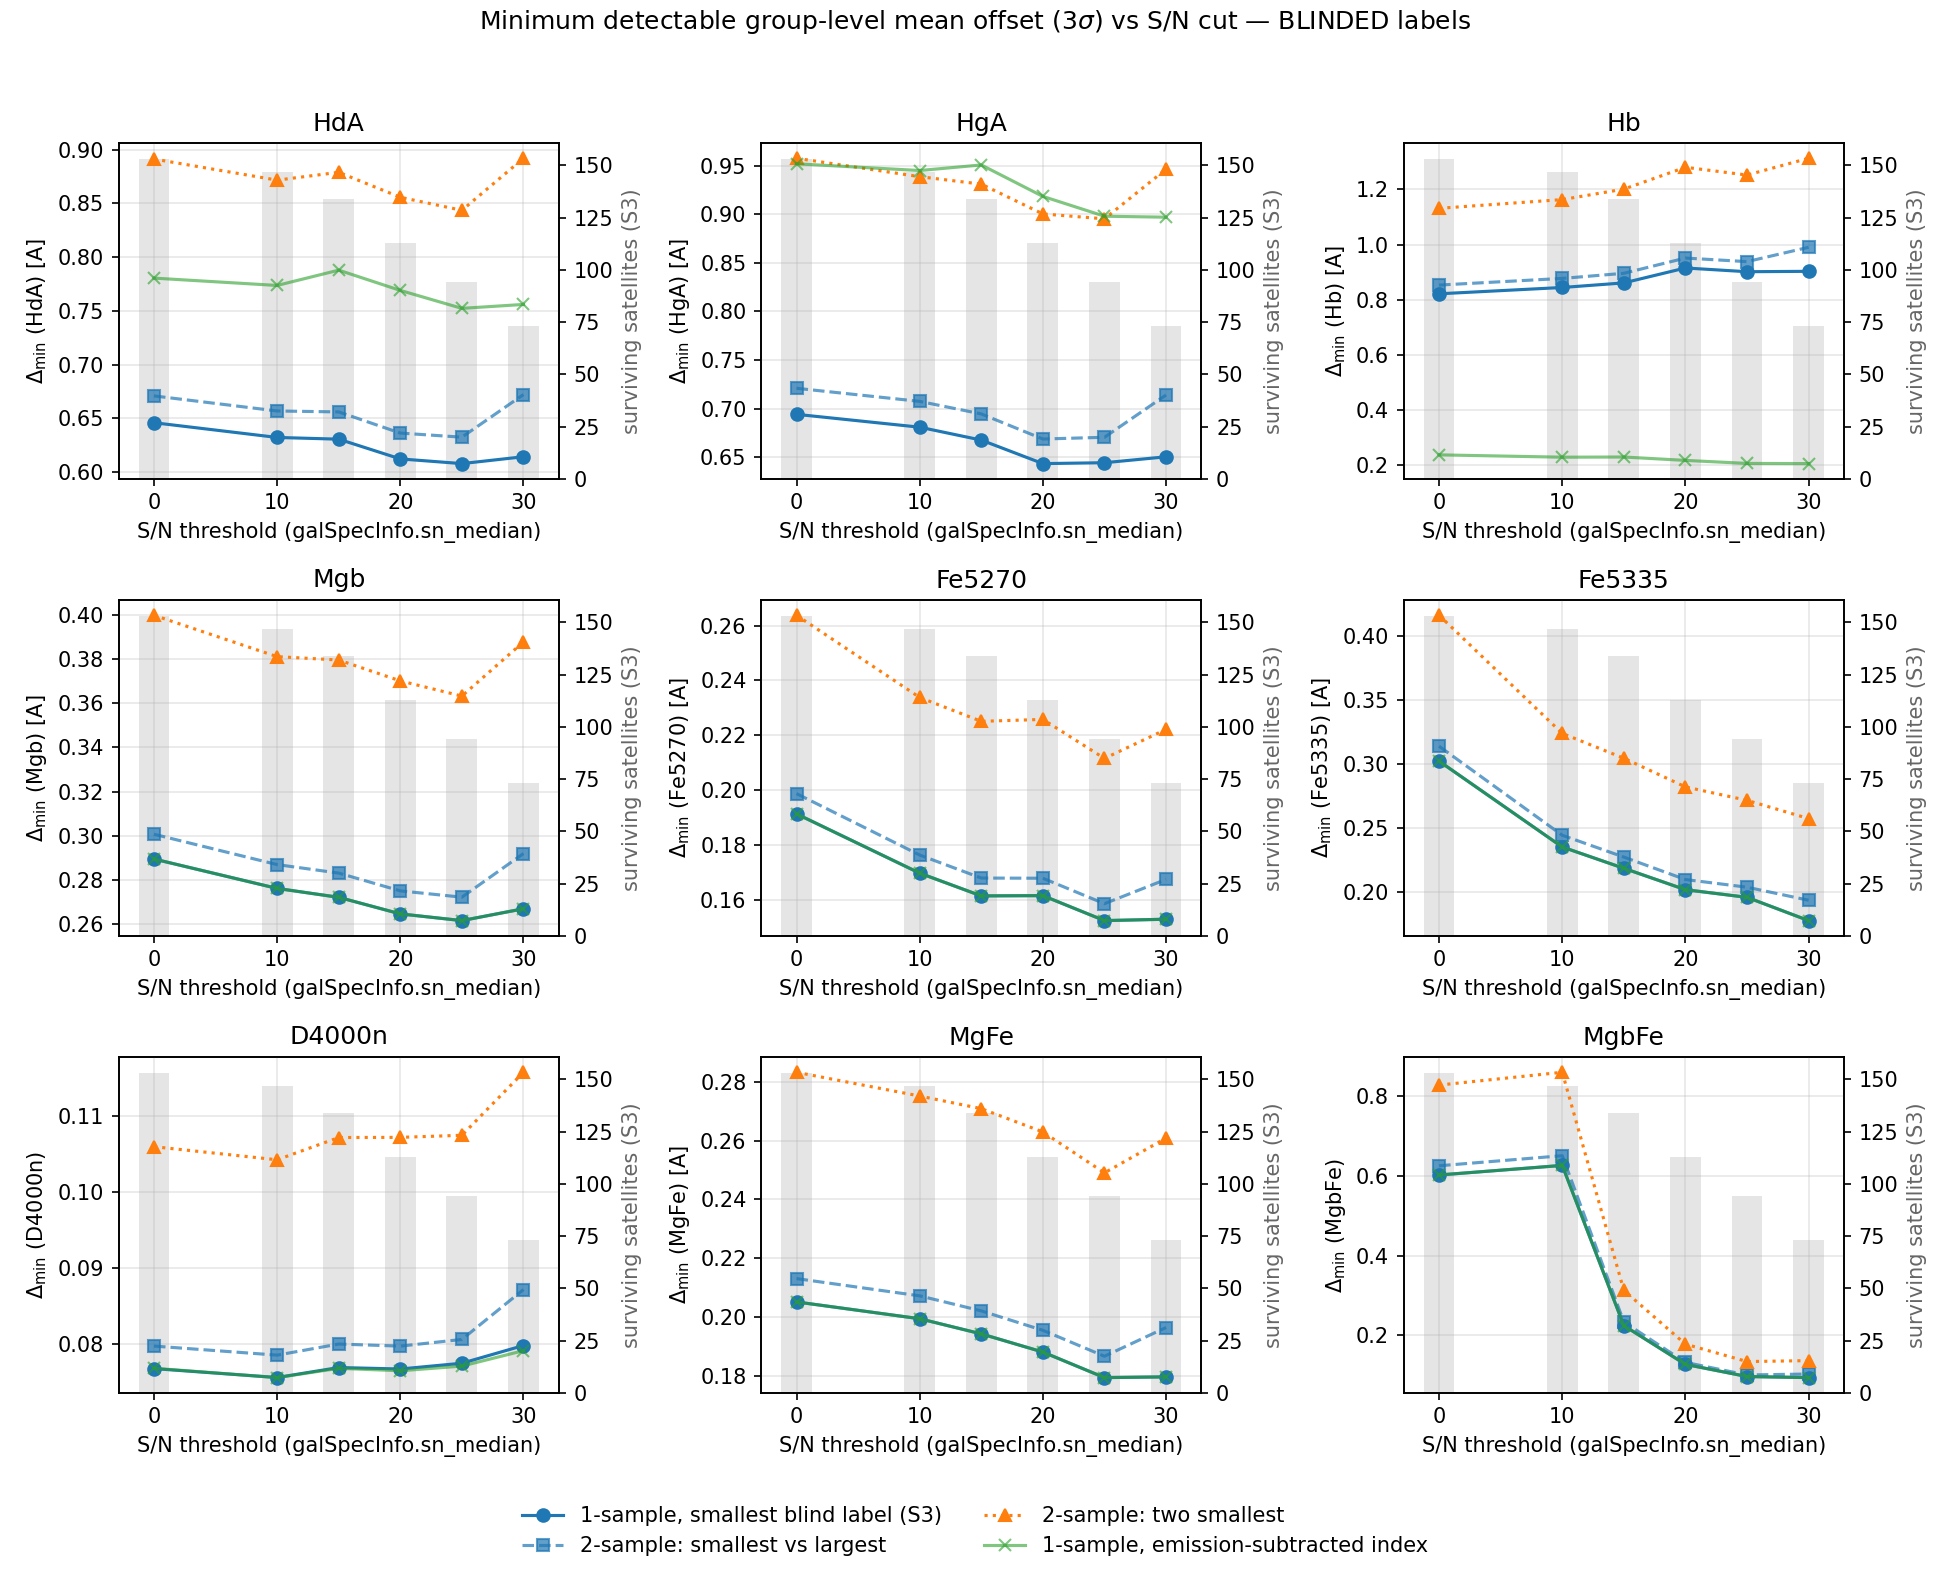

In [4]:
run("phase2_census_power.py", tail=0)
p2 = J()["phase2"]
cen = p2["census"]
rows = []
for t in p2["sn_thresholds"]:
    c = cen[str(t)]
    row = {"S/N >": t, "pooled all": c["pooled_dedup"]["all"], "pooled sat": c["pooled_dedup"]["sat"], "pooled BGG": c["pooled_dedup"]["bgg"]}
    for lab, v in c["by_blind_sample"].items():
        row[f"{lab} sat (groups)"] = f"{v['sat']} ({v['N_groups_with_ge1_sat']})"
    rows.append(row)
display(pd.DataFrame(rows))
dec = p2["decisive_SN20"]
display(Markdown(f"**S/N>{dec['threshold']:.0f}:** {dec['N_sat_surviving']}/{dec['N_sat_full']} = {100*dec['frac_sat_surviving']:.1f}% of satellites survive; "
                 f"survival by M_r quartile (bright→faint): {[round(v['frac_surv'],2) for v in dec['survival_by_M_r_quartile'].values()]}; "
                 f"by log M* quartile (low→high): {[round(v['frac_surv'],2) for v in dec['survival_by_lgm_quartile'].values()]}; "
                 f"fraction of survivors in the brightest quartile: {dec['frac_of_survivors_in_M_r_Q1']:.2f}"))
eb = p2["error_budget"]
display(pd.DataFrame({k: {e["bin"]: e["median_err"] for e in v} for k, v in eb["median_err_by_bin"].items() if not k.endswith("_sub")}).T)
display(pd.DataFrame(eb["satellite_scatter_vs_error"]).T)
pw = p2["power"]["by_threshold"]
rows = []
for t, e in pw.items():
    small = e["two_smallest_labels"][0]
    row = {"S/N >": int(t), "smallest label": small, "N_g": e["sizes"][small]["N_g"], "n_sat": round(e["sizes"][small]["n_sat"], 2)}
    for k in ["Mgb", "Fe5270", "Fe5335", "MgFe", "MgbFe", "Mg2", "D4000n", "HdA", "Hb_sub"]:
        v = e["indices"].get(k, {})
        row[f"Δmin {k}"] = v.get("per_blind_sample", {}).get(small, {}).get("delta_min")
        row[f"ρ {k}"] = v.get("rho_used")
    rows.append(row)
display(pd.DataFrame(rows).set_index("S/N >"))
display(pd.DataFrame(p2["yardsticks"]["by_threshold"]["20"]).T)
display(Image(os.path.join(HERE, p2["figure"]), width=1000))

> **GATE B** — reported in the session log; approval delegated by the author ("Do what you decide is the most relevant"). Decision: proceed.

## Phase 3 — Systematics (BLINDED)

{
 "HdA": {
  "delta_min_SN20_smallest": 0.6121361224257948,
  "aperture_shift_over_IQR_at_fixed_sigma": -0.24010471767190897,
  "z_shift_over_IQR_at_fixed_sigma": 0.05375180015374761,
  "morphology_E_minus_S_at_fixed_sigma": -0.8266994732857825,
  "ratio_aperture_over_delta_min": 0.3922407269814652,
  "ratio_morph_over_delta_min": 1.3505157480491568
 },
 "HgA": {
  "delta_min_SN20_smallest": 0.643442208320496,
  "aperture_shift_over_IQR_at_fixed_sigma": -0.19814796637807736,
  "z_shift_over_IQR_at_fixed_sigma": 0.27057475283278026,
  "morphology_E_minus_S_at_fixed_sigma": -0.7276526621358185,
  "ratio_aperture_over_delta_min": 0.30794990414955903,
  "ratio_morph_over_delta_min": 1.1308749297549618
 },
 "Hb": {
  "delta_min_SN20_smallest": 0.9150670659261309,
  "aperture_shift_over_IQR_at_fixed_sigma": 0.1600651538697673,
  "z_shift_over_IQR_at_fixed_sigma": 0.15191014240809664,
  "morphology_E_minus_S_at_fixed_sigma": 0.7407848814496625,
  "ratio_aperture_over_delta_min": 0.1749217733

,delta_min_SN20_smallest,aperture_shift_over_IQR_at_fixed_sigma,z_shift_over_IQR_at_fixed_sigma,morphology_E_minus_S_at_fixed_sigma,ratio_aperture_over_delta_min,ratio_morph_over_delta_min
HdA,0.612,-0.240,0.054,-0.827,0.392,1.351
HgA,0.643,-0.198,0.271,-0.728,0.308,1.131
Hb,0.915,0.160,0.152,0.741,0.175,0.810
Mgb,0.265,0.032,-0.056,0.206,0.122,0.777
Fe5270,0.161,0.008,-0.038,0.116,0.047,0.718
Fe5335,0.202,0.015,-0.046,0.113,0.076,0.562
Mg2,0.019,0.004,-0.002,0.020,0.212,1.081
D4000n,0.077,0.027,-0.023,0.105,0.352,1.367
MgFe,0.188,0.021,-0.046,0.158,0.113,0.842
MgbFe,0.127,0.015,0.034,0.016,0.120,0.129


,slope/dex apfrac,±,slope/dex apfrac @σ,±,slope/z @σ,±
HdA,0.067,0.164,-0.812,0.131,4.952,4.697
HgA,0.277,0.177,-0.670,0.140,24.930,4.745
Hb,-0.213,0.237,0.541,0.222,13.996,7.770
Mgb,-0.338,0.071,0.109,0.048,-5.154,1.538
Fe5270,-0.118,0.042,0.026,0.040,-3.536,1.367
Fe5335,-0.058,0.052,0.052,0.050,-4.242,2.093
Mg2,-0.018,0.005,0.014,0.003,-0.187,0.111
D4000n,-0.027,0.020,0.091,0.015,-2.142,0.547
MgFe,-0.199,0.049,0.072,0.039,-4.232,1.311
MgbFe,-0.039,0.034,0.052,0.031,3.099,1.227


Selection function P(S/N>20) logit coefficients per SD: {'const': 3.04, 'z_std': -1.04, 'lgm_std': 0.14, 'M_r_std': -2.1, 'R50_kpc_std': -1.43, 'sigma_std': 2.48}

,E−S @σ,±,raw median diff
HdA,-0.827,0.056,-1.672
HgA,-0.728,0.060,-1.715
Hb,0.741,0.085,0.297
Mgb,0.206,0.020,0.719
Fe5270,0.116,0.016,0.079
Fe5335,0.113,0.022,0.003
Mg2,0.020,0.001,0.062
D4000n,0.105,0.006,0.216
MgFe,0.158,0.016,0.308
MgbFe,0.016,0.013,0.199


,n,spearman,span_over_err_MgFe,resid_sd_over_median_err
HdA_vs_MgFe,2995,-0.803,10.487,1.97
HdA_sub_vs_MgFe,2995,-0.819,10.487,2.018
D4000n_vs_MgFe,2995,0.836,10.487,5.879
Hb_sub_vs_MgFe,2995,-0.707,10.487,1.399


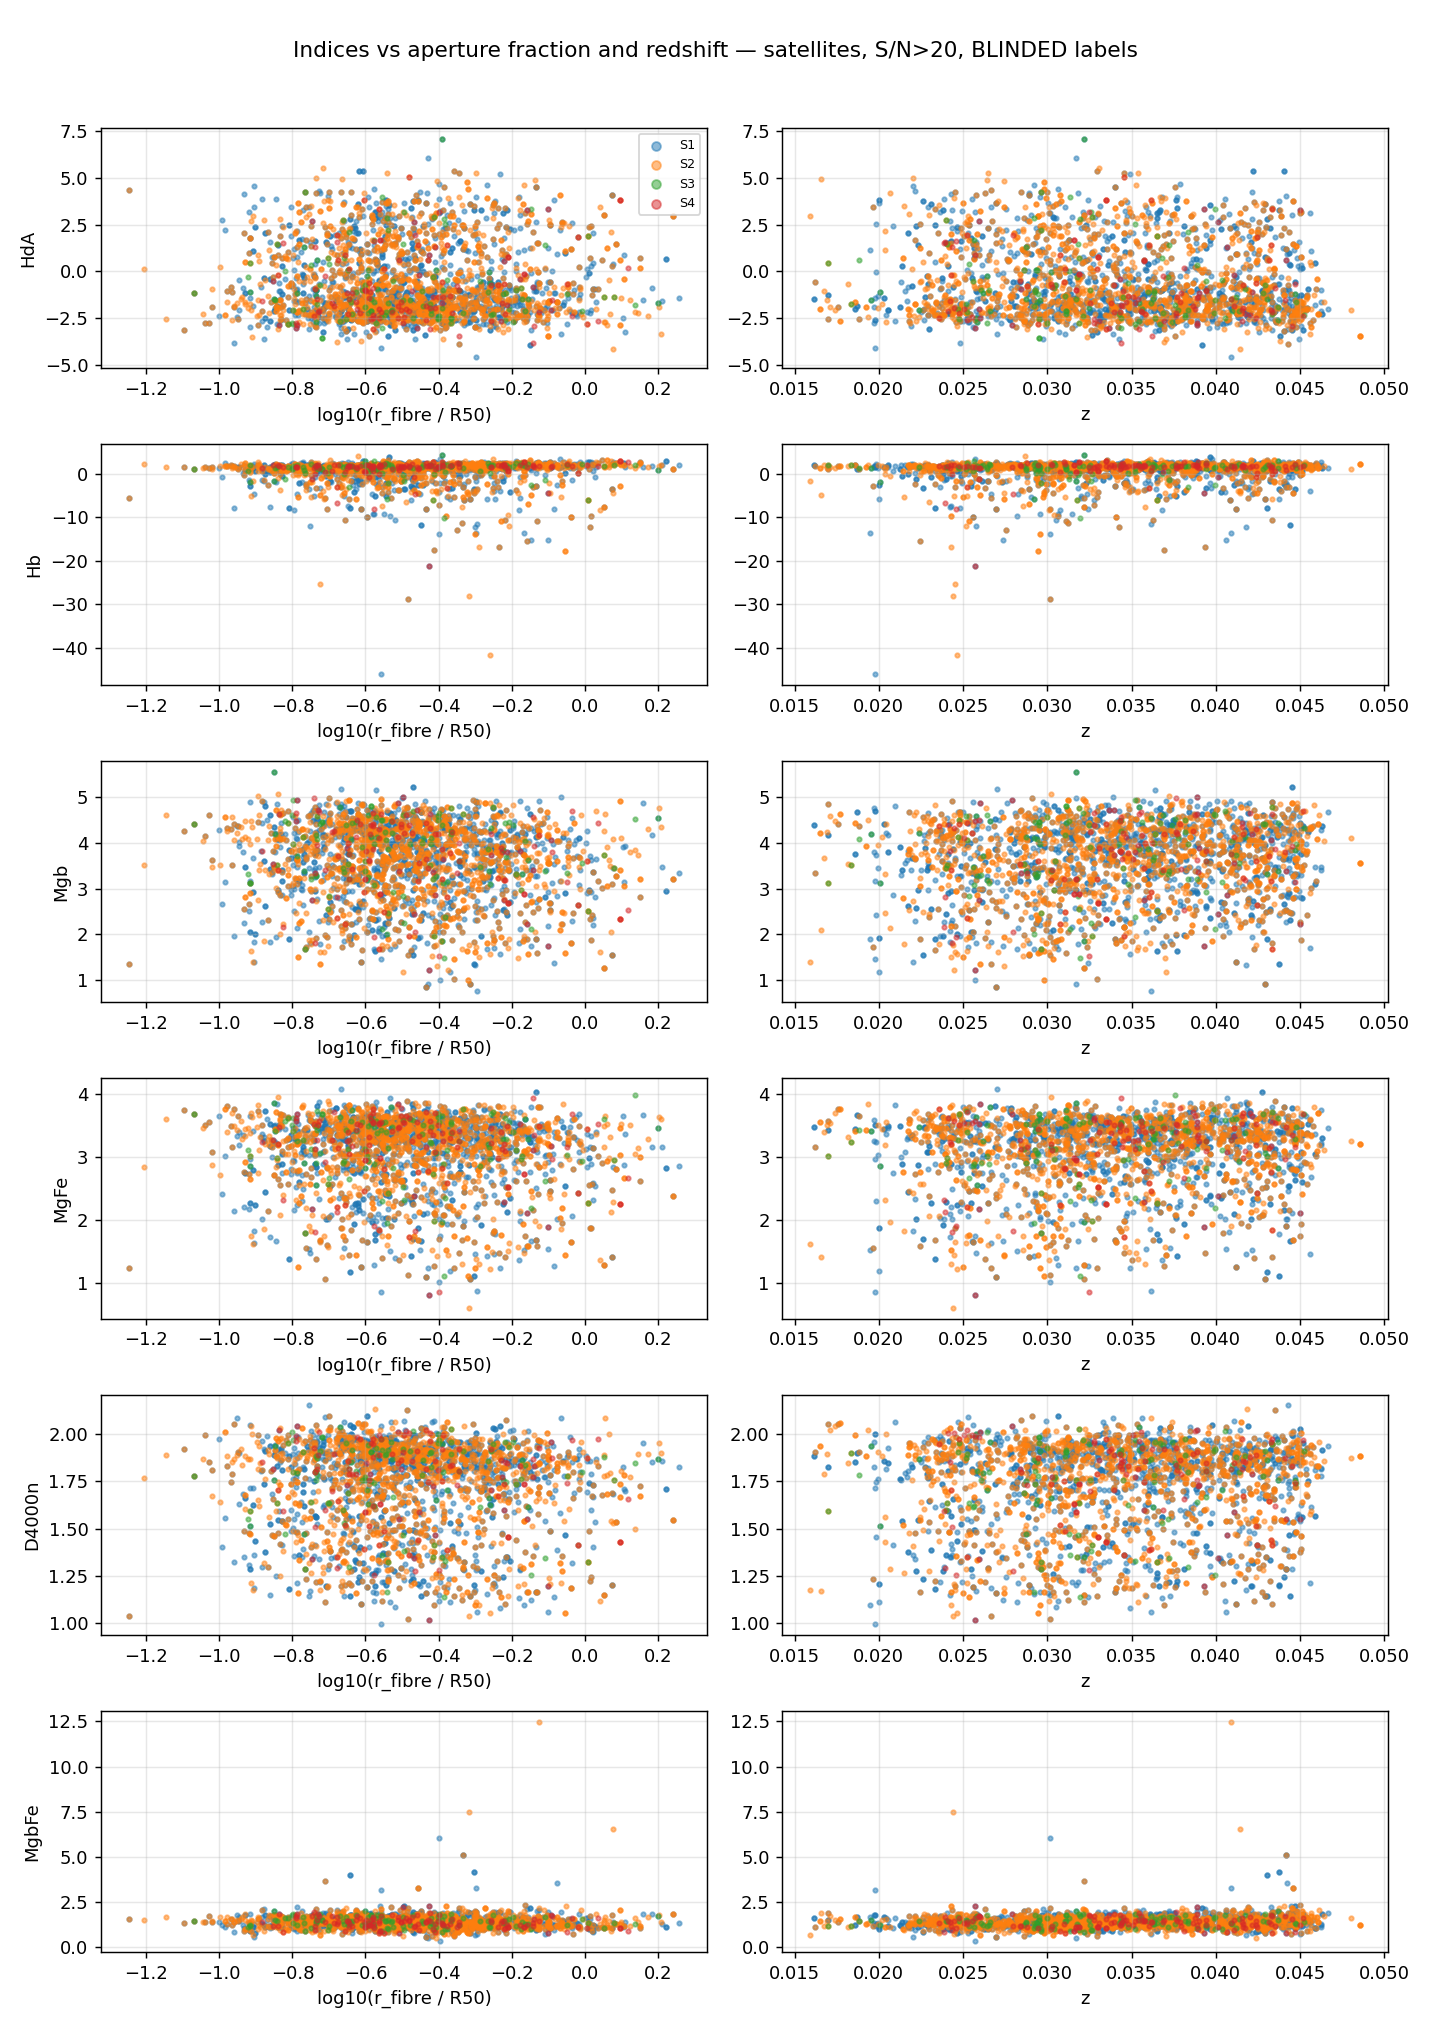

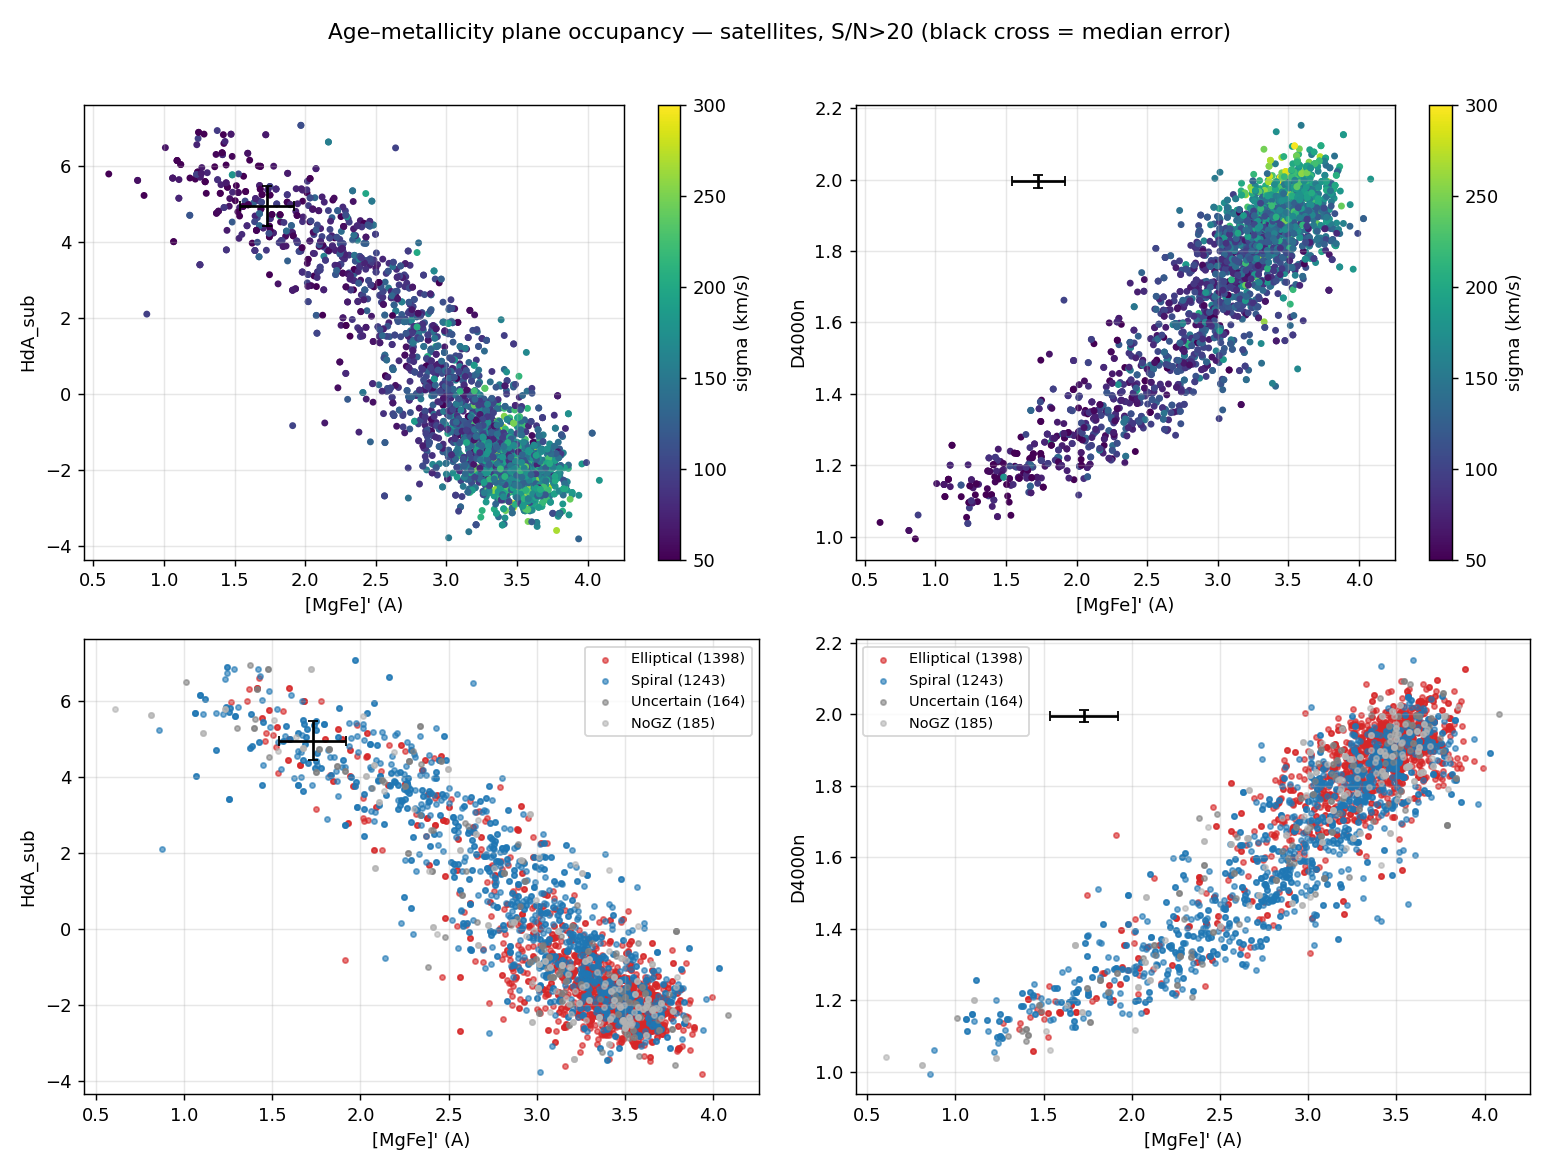

In [5]:
run("phase3_systematics.py", tail=0)
p3 = J()["phase3"]
display(pd.DataFrame(p3["systematics_vs_delta_min"]).T)
g = p3["aperture"]["gradients"]["SN_gt_20"]
display(pd.DataFrame({k: {"slope/dex apfrac": v["slope_per_dex_apfrac"], "±": v["se"], "slope/dex apfrac @σ": v["slope_per_dex_apfrac_at_fixed_sigma"], "± ": v["se_fixed_sigma"],
                          "slope/z @σ": v["slope_per_unit_z_at_fixed_sigma"], "±  ": v["se_z_fixed_sigma"]} for k, v in g.items()}).T)
sf = p3["balance"]["selection_function"]
display(Markdown(f"Selection function P(S/N>20) logit coefficients per SD: {dict((k, round(v, 2)) for k, v in sf['coef_per_SD'].items())}"))
m = p3["morphology_confound"]["by_SN_cut"]["SN_gt_20"]["indices"]
display(pd.DataFrame({k: {"E−S @σ": v["E_minus_S_at_fixed_sigma"], "±": v["se"], "raw median diff": v["E_minus_S_raw_median_diff"]} for k, v in m.items()}).T)
dg = p3["degeneracy"]
display(pd.DataFrame({k: v for k, v in dg.items() if isinstance(v, dict)}).T[["n", "spearman", "span_over_err_MgFe", "resid_sd_over_median_err"]])
display(Image(os.path.join(HERE, p3["aperture"]["figure"]), width=900))
display(Image(os.path.join(HERE, dg["figure"]), width=900))

> **GATE C** — unblinding. The blinded JSON was frozen first (`outputs/PREUNBLIND_SHA256.txt`). Approval delegated by the author; Phase 4 proceeds only because no
> Phase 3 systematic exceeds Δ_min by more than the morphology term, which the Phase 4 design controls by construction.
>
> **Phase 4 is an exploratory scoping run, not an inference: no p-values, no multiple-comparison correction.** Set `UNBLIND = False` to skip it.

host members: 958 rows in 54 hosts; CG members=224, non-CG=734
-> /Users/matt/Astrophysics/CG_Gals/exploration/metallicity/work/host_members_worktable_raw.csv: (958, 160); spec_choice={'csv_specobjid_with_mpa': 932, 'other_no_mpa': 26}


variant all_valid ...
variant SN_gt_20 ...

=== all_valid: galaxy-level CG4 - control at fixed morphology & sigma (coef ± cluster SE [68% CI]) ===
  Mgb      C4B: +0.105±0.058 [+0.050,+0.161] | C4C: +0.044±0.058 [-0.016,+0.102] | RG4: +0.128±0.092 [+0.042,+0.223]   (Δmin≈0.290)
  Fe5270   C4B: +0.009±0.049 [-0.037,+0.057] | C4C: -0.003±0.049 [-0.055,+0.042] | RG4: -0.065±0.095 [-0.164,+0.025]   (Δmin≈0.191)
  Fe5335   C4B: +0.001±0.060 [-0.057,+0.062] | C4C: -0.008±0.062 [-0.066,+0.052] | RG4: +0.121±0.144 [-0.021,+0.251]   (Δmin≈0.302)
  MgFe     C4B: +0.040±0.045 [-0.004,+0.086] | C4C: +0.002±0.045 [-0.041,+0.051] | RG4: +0.040±0.075 [-0.037,+0.119]   (Δmin≈0.205)
  MgbFe    C4B: -0.064±0.080 [-0.140,+0.018] | C4C: -0.050±0.059 [-0.102,+0.008] | RG4: -0.105±0.155 [-0.268,+0.051]   (Δmin≈0.602)
  Mg2      C4B: +0.007±0.003 [+0.004,+0.010] | C4C: +0.004±0.003 [+0.000,+0.007] | RG4: +0.005±0.005 [-0.000,+0.011]   (Δmin≈0.019)
  D4000n   C4B: +0.029±0.015 [+0.015,+0.044] | C4C: +0.007±0.

**EXPLORATORY SCOPING RUN, NOT AN INFERENCE: no p-values are reported and no multiple-comparison correction is applied, so that no prespecified Paper III analysis is contaminated. Point estimates with group-clustered SEs and group-bootstrap percentile CIs only.**

,N_sat,N_usable,N_usable_SN_gt_20,N_usable_SN_gt_30,N_groups_with_usable_sat,N_groups_with_usable_sat_SN_gt_20,median_M_r_usable,median_M_r_usable_SN_gt_20
CG4,186.0,168.0,120.0,61.0,62.0,60.0,-20.414,-20.711
RG4,168.0,159.0,78.0,27.0,56.0,48.0,-20.178,-20.745
Control4B,2094.0,1917.0,1510.0,993.0,696.0,666.0,-20.958,-21.165
Control4C,2109.0,1899.0,1284.0,697.0,700.0,651.0,-20.364,-20.717


**Variant `all_valid`** (coef ± group-clustered SE; CG4 − control at fixed morphology & σ)

,Con4B all,Con4B ell,Con4B spi,Con4C all,Con4C ell,Con4C spi,RG4G4 all,RG4G4 ell,RG4G4 spi,within-host,Δmin (no cut)
index,,,,,,,,,,,
Mgb,+0.105±0.058,+0.148±0.054,+0.165±0.092,+0.044±0.058,+0.087±0.054,+0.140±0.091,+0.128±0.092,+0.159±0.092,+0.236±0.120,-0.008±0.077,0.290
Fe5270,+0.009±0.049,+0.037±0.048,-0.010±0.097,-0.003±0.049,+0.040±0.048,-0.008±0.097,-0.065±0.095,+0.034±0.100,-0.113±0.142,-0.069±0.089,0.191
Fe5335,+0.001±0.060,-0.023±0.071,+0.041±0.104,-0.008±0.062,-0.061±0.072,+0.116±0.110,+0.121±0.144,+0.054±0.107,+0.244±0.234,-0.095±0.087,0.302
MgFe,+0.040±0.045,+0.071±0.042,+0.074±0.075,+0.002±0.045,+0.046±0.042,+0.061±0.075,+0.040±0.075,+0.091±0.079,+0.113±0.097,-0.045±0.069,0.205
MgbFe,-0.064±0.080,+0.078±0.036,-0.174±0.178,-0.050±0.059,+0.037±0.041,-0.122±0.140,-0.105±0.155,+0.062±0.046,-0.184±0.295,-0.052±0.079,0.602
Mg2,+0.007±0.003,+0.008±0.003,+0.011±0.005,+0.004±0.003,+0.004±0.003,+0.009±0.005,+0.005±0.005,+0.004±0.007,+0.010±0.006,-0.002±0.004,0.019
D4000n,+0.029±0.015,+0.034±0.016,+0.048±0.023,+0.007±0.015,+0.015±0.016,+0.035±0.023,+0.024±0.024,+0.016±0.031,+0.047±0.029,-0.037±0.021,0.077
HdA_sub,-0.466±0.175,-0.418±0.189,-0.688±0.306,-0.203±0.174,-0.218±0.188,-0.524±0.311,-0.554±0.285,-0.376±0.366,-0.844±0.366,+0.446±0.217,0.780
Hb_sub,-0.146±0.053,-0.131±0.058,-0.210±0.087,-0.068±0.052,-0.070±0.058,-0.153±0.087,-0.224±0.096,-0.156±0.127,-0.277±0.123,+0.134±0.088,0.237


**Variant `SN_gt_20`** (coef ± group-clustered SE; CG4 − control at fixed morphology & σ)

,Con4B all,Con4B ell,Con4B spi,Con4C all,Con4C ell,Con4C spi,RG4G4 all,RG4G4 ell,RG4G4 spi,within-host,Δmin (no cut)
index,,,,,,,,,,,
Mgb,+0.124±0.051,+0.112±0.047,+0.197±0.085,+0.054±0.051,+0.054±0.047,+0.152±0.088,+0.153±0.085,+0.162±0.084,+0.265±0.131,+0.098±0.062,0.290
Fe5270,+0.067±0.041,+0.046±0.043,+0.160±0.074,+0.042±0.041,+0.030±0.043,+0.146±0.074,+0.131±0.075,+0.112±0.079,+0.219±0.115,-0.005±0.077,0.191
Fe5335,-0.014±0.068,-0.039±0.075,+0.101±0.131,-0.043±0.068,-0.057±0.074,+0.099±0.131,+0.160±0.103,+0.054±0.105,+0.366±0.187,-0.038±0.091,0.302
MgFe,+0.076±0.042,+0.055±0.037,+0.171±0.076,+0.034±0.043,+0.024±0.037,+0.145±0.077,+0.147±0.073,+0.122±0.067,+0.270±0.109,+0.031±0.059,0.205
MgbFe,+0.054±0.031,+0.065±0.037,+0.052±0.063,+0.020±0.034,+0.030±0.042,+0.032±0.063,-0.016±0.062,+0.042±0.046,-0.059±0.138,+0.071±0.038,0.602
Mg2,+0.009±0.004,+0.008±0.003,+0.016±0.006,+0.004±0.004,+0.003±0.003,+0.013±0.006,+0.009±0.006,+0.008±0.007,+0.015±0.009,+0.005±0.005,0.019
D4000n,+0.038±0.019,+0.037±0.015,+0.085±0.038,+0.010±0.019,+0.013±0.014,+0.066±0.038,+0.041±0.029,+0.035±0.026,+0.095±0.049,+0.008±0.024,0.077
HdA_sub,-0.466±0.208,-0.381±0.157,-1.127±0.413,-0.191±0.209,-0.163±0.155,-0.922±0.427,-0.493±0.352,-0.486±0.324,-1.017±0.519,-0.192±0.245,0.780
Hb_sub,-0.143±0.061,-0.164±0.053,-0.218±0.121,-0.065±0.062,-0.097±0.053,-0.148±0.124,-0.220±0.097,-0.296±0.098,-0.190±0.148,-0.091±0.088,0.237


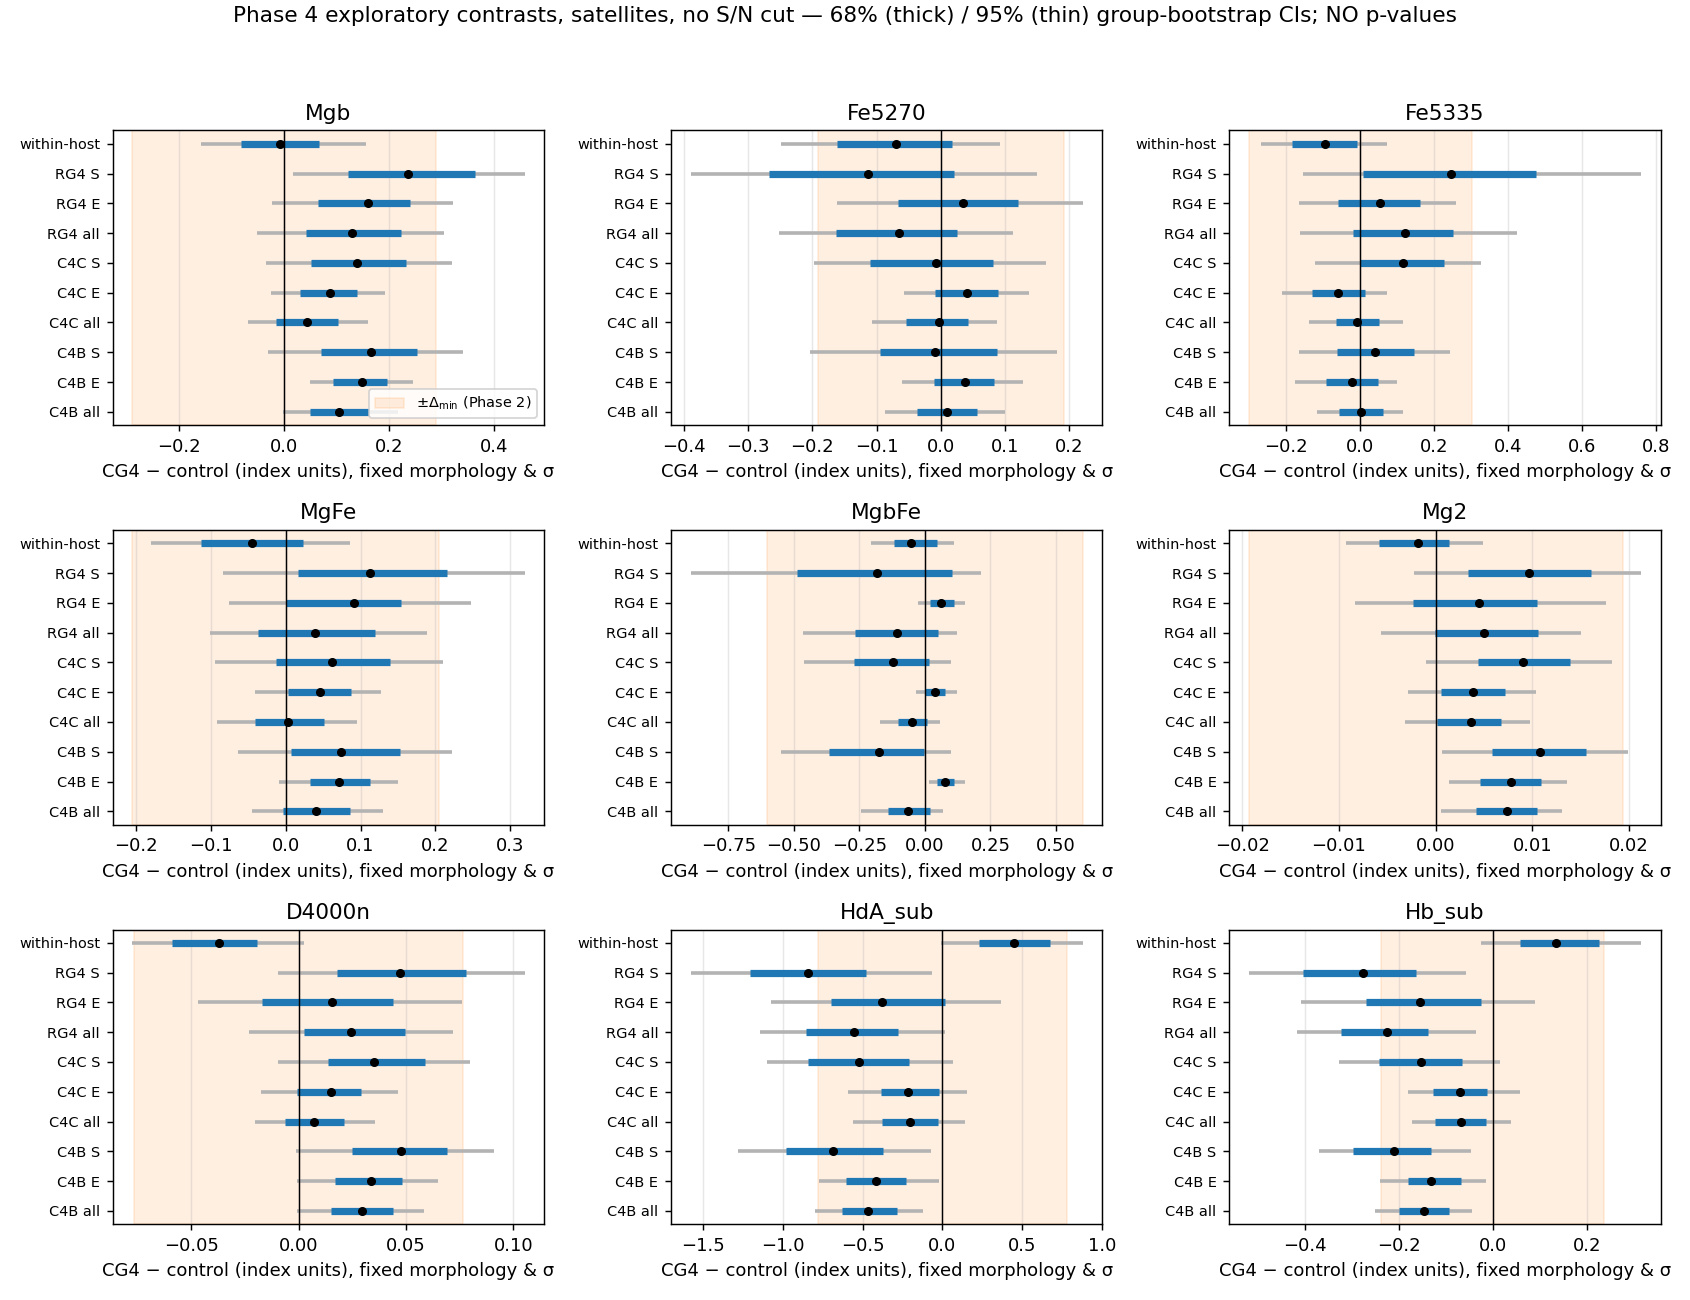

In [6]:
UNBLIND = True
if UNBLIND:
    run("phase4_fetch_hosts.py", tail=2)
    run("phase4_unblinded.py", tail=0)
    p4 = J()["phase4"]
    display(Markdown(f"**{p4['statement']}**"))
    display(pd.DataFrame(p4["true_label_census_satellites"]).T)
    for variant in ["all_valid", "SN_gt_20"]:
        a = p4["results"][variant]["a_galaxy_level"]; w = p4["results"][variant]["d_within_host"]["satellites_only"]
        rows = []
        for k in ["Mgb", "Fe5270", "Fe5335", "MgFe", "MgbFe", "Mg2", "D4000n", "HdA_sub", "Hb_sub"]:
            row = {"index": k}
            for c in ["Control4B", "Control4C", "RG4"]:
                for sub in ["all_morph", "ellipticals", "spirals"]:
                    v = a[c]["indices"].get(k, {}).get(sub)
                    row[f"{c[:3]}{c[-2:]} {sub[:3]}"] = None if v is None else f"{v['coef']:+.3f}±{v['cluster_se']:.3f}"
            v = w["indices"].get(k)
            row["within-host"] = None if v is None else f"{v['coef']:+.3f}±{v['cluster_se']:.3f}"
            row["Δmin (no cut)"] = p4["delta_min_reference_SN0_smallest_label"].get(k)
            rows.append(row)
        display(Markdown(f"**Variant `{variant}`** (coef ± group-clustered SE; CG4 − control at fixed morphology & σ)"))
        display(pd.DataFrame(rows).set_index("index"))
    display(Image(os.path.join(HERE, p4["figure"]), width=1000))

## Phase 5 — Report and repository check

In [7]:
run("phase5_report.py", tail=0)
display(Markdown(open(os.path.join(HERE, "REPORT.md")).read()))
status = subprocess.run(["git", "status", "--porcelain"], cwd=REPO, capture_output=True, text=True).stdout
print(status)
mine = [l for l in status.splitlines() if l.strip().endswith("exploration/")]
others = [l for l in status.splitlines() if not l.strip().endswith("exploration/")]
print("untracked path written by this study:", mine)
print("other entries (pre-existing tmp/ or concurrent-session edits; not written by this study):", others)

# Stellar-population index feasibility for CG4 satellites — scoping report

*Auto-generated from `outputs/metallicity_scoping.json` (`submission-qc-float-fix` @ `7367e51`). Exploratory scoping, not inference: no p-values, no multiplicity correction.*

## 1. What data exist
- Locally: the four sample tables, the pipeline SDSS cache (69995 rows; `galSpecExtra`/`galSpecLine`/`zooSpec` only) and the size caches. **No** `galSpecIndx`, per-galaxy σ or spectrum S/N existed locally.
- Fetched (path A; SkyServer DR18 because the DR16 host fails TLS — `galSpec*` are the unchanged MPA-JHU DR8 tables): `galSpecIndx` (indices, errors, raw + emission-subtracted), `galSpecInfo` (`v_disp`, `sn_median`, `reliable`), `SpecObjAll` cross-checks, for 3857 objids + 958 Lim-host members. Cached under `work/`.
- Datamodel (primary sources saved in `work/`): Å for atomic indices, mag for Mg2; Lick EW sign convention (verified: quenched median Mgb 4.19 Å, HδA -1.95 Å); no σ-broadening correction is applied to t

# Stellar-population index feasibility for CG4 satellites — scoping report

*Auto-generated from `outputs/metallicity_scoping.json` (`submission-qc-float-fix` @ `7367e51`). Exploratory scoping, not inference: no p-values, no multiplicity correction.*

## 1. What data exist
- Locally: the four sample tables, the pipeline SDSS cache (69995 rows; `galSpecExtra`/`galSpecLine`/`zooSpec` only) and the size caches. **No** `galSpecIndx`, per-galaxy σ or spectrum S/N existed locally.
- Fetched (path A; SkyServer DR18 because the DR16 host fails TLS — `galSpec*` are the unchanged MPA-JHU DR8 tables): `galSpecIndx` (indices, errors, raw + emission-subtracted), `galSpecInfo` (`v_disp`, `sn_median`, `reliable`), `SpecObjAll` cross-checks, for 3857 objids + 958 Lim-host members. Cached under `work/`.
- Datamodel (primary sources saved in `work/`): Å for atomic indices, mag for Mg2; Lick EW sign convention (verified: quenched median Mgb 4.19 Å, HδA -1.95 Å); no σ-broadening correction is applied to the data (the models are broadened to each galaxy's σ, Kauffmann+03a §2); Lick/IDS transformation **UNRESOLVED** (§6); MPA rows zeroed with `plateid=-1` when not run, `_err=-1` = index not measured.
- Sentinel finding: the Fe5335 (104) and Mg2 (115) `_err=-1` flags cluster at z = 0.0398–0.0408, where the red pseudo-continuum meets the 5577 Å sky line → a z-dependent hole in Fe5335/[MgFe]′.

## 2. How many satellites are usable, and which
| sample | sat input | MPA result | 7 indices valid | + σ + S/N | S/N>20 | S/N>30 |
|---|---:|---:|---:|---:|---:|---:|
| CG4 | 186 | 177 | 172 | 168 (62 groups) | 120 (60) | 61 |
| RG4 | 168 | 166 | 163 | 159 (56 groups) | 78 (48) | 27 |
| Control4B | 2094 | 1995 | 1943 | 1917 (696 groups) | 1510 (666) | 993 |
| Control4C | 2109 | 1996 | 1945 | 1899 (700 groups) | 1284 (651) | 697 |
| pooled (dedup) | 3092 | – | 2864 | – | 2055 | 1241 |

Galaxy-by-galaxy list (objid, group, S/N, indices, loss reason): `outputs/usable_satellites.csv`.
CG4 satellite losses: 9 no_MPA_result(BOSS/not-run), 5 core_index_missing_or_zeroed, 4 sigma_invalid. The S/N>20 cut is differential between samples (CG4 71%, RG4 49%, Control4B 79%, Control4C 68% of usable satellites kept).
**Decisive question.** At S/N > 20, 66% of satellites survive (2055/3092). They are **not** just the brightest quartile (34% of survivors come from it), but the selection is strongly graded: survival by M_r quartile (bright→faint) 91% / 80% / 60% / 35%; by stellar-mass quartile (low→high) 27% / 65% / 90% / 97%; survivors are 0.32 mag brighter and 0.19 dex more massive at the median. Logistic selection per SD: M_r -2.10, σ +2.48, R50 -1.43, z -1.04: a hard S/N cut breaks matched balance in luminosity, size and redshift.

## 3. Δ_min per index (3σ group-level mean offset; blinded labels)
Smallest blinded label at S/N>20: N_g = 52, n̄_sat = 2.17; ρ = empirical one-way ICC (group bootstrap); σ_idx = total satellite scatter, of which measurement error is only 34% (Mgb) / 30% ([MgFe]′).

| index | unit | median err @S/N 20–25 | ρ | Δ_min (S/N>20) | Δ_min (no cut) | 2-sample, smallest vs largest | Δ_min/IQR |
|---|---|---:|---:|---:|---:|---:|---:|
| Mgb | A | 0.429 | 0.17 | **0.265** | 0.290 | 0.275 | 0.22 |
| Fe5270 | A | 0.446 | 0.16 | **0.161** | 0.191 | 0.168 | 0.29 |
| Fe5335 | A | 0.453 | 0.16 | **0.202** | 0.302 | 0.209 | 0.36 |
| MgFe | A | 0.276 | 0.18 | **0.188** | 0.205 | 0.196 | 0.27 |
| MgbFe |  | 0.241 | 0.10 | **0.127** | 0.602 | 0.132 | 0.35 |
| Mg2 | mag | 0.014 | 0.19 | **0.019** | 0.019 | 0.020 | 0.22 |
| D4000n |  | 0.026 | 0.18 | **0.077** | 0.077 | 0.080 | 0.22 |
| HdA | A | 0.799 | 0.17 | **0.612** | 0.646 | 0.636 | 0.22 |
| Hb_sub | A | 0.420 | 0.15 | **0.217** | 0.237 | 0.226 | – |

Δ_min is nearly flat against the S/N threshold (intrinsic scatter dominates): the cut buys little power while imposing the graded selection of §2. Raw Hβ is unusable (emission fill-in); use `_sub`. Figure: `figures/fig_power_vs_SN.png`.

## 4. Dominant systematic (blinded)
| index | Δ_min (S/N>20) | aperture shift over IQR(r_fib/R50) at fixed σ | z shift over IQR(z) at fixed σ | GZ1 E−S at fixed σ | morph/Δ_min |
|---|---:|---:|---:|---:|---:|
| Mgb | 0.265 | +0.032 | -0.056 | +0.206 | 0.78 |
| Fe5270 | 0.161 | +0.008 | -0.038 | +0.116 | 0.72 |
| Fe5335 | 0.202 | +0.015 | -0.046 | +0.113 | 0.56 |
| MgFe | 0.188 | +0.021 | -0.046 | +0.158 | 0.84 |
| MgbFe | 0.127 | +0.015 | +0.034 | +0.016 | 0.13 |
| Mg2 | 0.019 | +0.004 | -0.002 | +0.020 | 1.08 |
| D4000n | 0.077 | +0.027 | -0.023 | +0.105 | 1.37 |
| HdA | 0.612 | -0.240 | +0.054 | -0.827 | 1.35 |

- Aperture (1.5″ fibre radius / Simard R_chl,r, Petrosian fallback; Planck15 angular-diameter distance): median r_fib/R50 = 0.33 (IQR 0.24–0.47); metal-line gradients at fixed σ are ≤ 0.12 Δ_min over the IQR — subdominant, as is redshift.
- **Morphology is the dominant systematic**: at fixed σ, GZ1 ellipticals − spirals = +0.21 Å (Mgb), +0.16 Å ([MgFe]′), +0.105 (Dn4000), -0.83 Å (HδA) — 0.6–1.4 × Δ_min, and σ-dependent (Mgb E−S +0.57 Å at σ<80 vs +0.11 at 160–220 km/s). Since CG4's headline result is a morphology excess, any index signal must be measured within morphology class. Mgb/⟨Fe⟩ is morphology-independent at fixed σ (+0.016).
- Age–Z plane: HδA_sub vs [MgFe]′ Spearman -0.82, Dn4000 vs [MgFe]′ 0.84; residual width at fixed [MgFe]′ is 2.0× (HδA) / 5.9× (Dn4000) the median error: real width at population level, marginal per galaxy.

## 5. Exploratory unblinded contrasts (Phase 4; no inference)
CG4 − control, satellites, fixed morphology & σ, no S/N cut (coef ± group-clustered SE [68% group-bootstrap CI]); last column = within-host fixed-effects analogue of the conditional-logit design:

| index | vs C4B | vs C4C | vs RG4 | within-host (sat.) | Δ_min (no cut) |
|---|---|---|---|---|---:|
| Mgb | +0.105 ± 0.058 [+0.05,+0.16] | +0.044 ± 0.058 [-0.02,+0.10] | +0.128 ± 0.092 [+0.04,+0.22] | -0.008 ± 0.077 | 0.290 |
| Fe5270 | +0.009 ± 0.049 [-0.04,+0.06] | -0.003 ± 0.049 [-0.05,+0.04] | -0.065 ± 0.095 [-0.16,+0.02] | -0.069 ± 0.089 | 0.191 |
| Fe5335 | +0.001 ± 0.060 [-0.06,+0.06] | -0.008 ± 0.062 [-0.07,+0.05] | +0.121 ± 0.144 [-0.02,+0.25] | -0.095 ± 0.087 | 0.302 |
| MgFe | +0.040 ± 0.045 [-0.00,+0.09] | +0.002 ± 0.045 [-0.04,+0.05] | +0.040 ± 0.075 [-0.04,+0.12] | -0.045 ± 0.069 | 0.205 |
| MgbFe | -0.064 ± 0.080 [-0.14,+0.02] | -0.050 ± 0.059 [-0.10,+0.01] | -0.105 ± 0.155 [-0.27,+0.05] | -0.052 ± 0.079 | 0.602 |
| Mg2 | +0.007 ± 0.003 [+0.00,+0.01] | +0.004 ± 0.003 [+0.00,+0.01] | +0.005 ± 0.005 [-0.00,+0.01] | -0.002 ± 0.004 | 0.019 |
| D4000n | +0.029 ± 0.015 [+0.02,+0.04] | +0.007 ± 0.015 [-0.01,+0.02] | +0.024 ± 0.024 [+0.00,+0.05] | -0.037 ± 0.021 | 0.077 |
| HdA_sub | -0.466 ± 0.175 [-0.63,-0.28] | -0.203 ± 0.174 [-0.38,-0.03] | -0.554 ± 0.285 [-0.86,-0.28] | +0.446 ± 0.217 | 0.780 |
| Hb_sub | -0.146 ± 0.053 [-0.20,-0.09] | -0.068 ± 0.052 [-0.12,-0.02] | -0.224 ± 0.096 [-0.32,-0.14] | +0.134 ± 0.088 | 0.237 |

All metal-line contrasts are below Δ_min (mostly ≤ 0.4 Δ_min) and consistent with zero; Balmer/Dn4000 offsets vs C4B/RG4 are ~2 SE (older-looking CG4 satellites) but ≈ 0 vs C4C, and the within-host contrasts flip sign between the no-cut and S/N>20 variants. Nothing here is a detection.

## 6. Recommendation and unresolved items
**Go/no-go: conditional GO — only as a prespecified, within-morphology, S/N-uncut, error-weighted design.** N is adequate (168 usable CG4 satellites in 62 groups; 120 at S/N>20), Δ_min ≈ 0.22 × IQR (0.26 Å Mgb, 0.19 Å [MgFe]′) and no systematic swamps it; but morphology ≈ Δ_min and the S/N cut is differential, so Paper III must (i) replace the hard S/N cut by measurement-error weighting, (ii) stratify/match on GZ1 class and σ, (iii) take C4C as primary control, (iv) prespecify before any SSP fitting. The exploratory contrasts show no metal-line effect above ~0.4 Δ_min.

UNRESOLVED (not verifiable from primary sources consulted):
1. Lick/IDS resolution transformation of the MPA indices: UNRESOLVED (explicit statement absent); strong indirect evidence for native SDSS resolution.
2. Dn4000 flux-density convention (F_ν vs F_λ): not stated in the catalogue docs (Kauffmann+03a define D4000 via F_ν).
3. The `_err = -1` convention is inferred empirically (datamodel text only describes whole-row zeroing).
4. DR18 = DR16 `galSpecIndx` rows is asserted from the run2d=26-only coverage statement and the 100% `specobjid` cross-match, not a row-level DR16 diff (endpoint unreachable).
5. Blinded balance tests are null by construction; true-label balance after an S/N cut was not tested (only the differential survival above).

`git status --porcelain` at report time: 9 entries (`exploration/` plus pre-existing/concurrent-session paths; see INVENTORY.md and the final session log).


 M output/paper/paper.aux
 M output/paper/paper.pdf
 M output/paper/paper.tex
 M src/paper_template/paper_template.tex
 M tests/test_size_render_smoke.py
?? exploration/
?? referee/T10_ds18_morphology.py
?? referee/values/T10.json
?? tmp/

untracked path written by this study: ['?? exploration/']
other entries (pre-existing tmp/ or concurrent-session edits; not written by this study): [' M output/paper/paper.aux', ' M output/paper/paper.pdf', ' M output/paper/paper.tex', ' M src/paper_template/paper_template.tex', ' M tests/test_size_render_smoke.py', '?? referee/T10_ds18_morphology.py', '?? referee/values/T10.json', '?? tmp/']
